In [84]:
import torch
from torch import nn
import torch.nn.functional as F
import numpy as np
from torch_geometric.nn.conv import GATConv, GCNConv, SplineConv
from torch_geometric.nn.norm import GraphNorm
from torch_geometric.nn import Sequential
from torch_geometric.data import Data, Batch
from dataset import WaveletDataset
from torch_geometric.loader import DataLoader
import torch.utils.data as torchdata
import tqdm
from math import floor
import gc
import matplotlib.pyplot as plt 
from Model.MENDR.mAtt.optimizer import MixOptimizer
import random
import os
import math
from dataset import WaveletTUABDataset
from sklearn.metrics import accuracy_score, balanced_accuracy_score, roc_auc_score, precision_recall_curve, auc
from Finetuning.biot import BIOTEncoder, ClassificationHead
from torch.utils.data import Subset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [138]:
print("*" * 50)
finetune_train_dataset = WaveletTUABDataset(root="/home/hice1/mchen439/scratch/downstreamTaskData/train")
#indices = torch.arange(60000)
finetune_train_dataset = Subset(finetune_train_dataset, indices)
print("Dataset Loaded. Length of Train Dataset: ", len(finetune_train_dataset))
finetune_eval_dataset = WaveletTUABDataset(root="/home/hice1/mchen439/scratch/downstreamTaskData/eval")
print("Dataset Loaded. Length of Validation Dataset: ", len(finetune_eval_dataset))

**************************************************
Loading 2130 folders


100%|██████████| 2130/2130 [01:57<00:00, 18.15it/s]


Dataset Loaded. Length of Train Dataset:  60000
Loading 253 folders


100%|██████████| 253/253 [00:11<00:00, 22.42it/s]

Dataset Loaded. Length of Validation Dataset:  30606


In [139]:
finetune_train_loader = DataLoader(finetune_train_dataset, batch_size=128, num_workers=2, shuffle=True)
finetune_eval_loader = DataLoader(finetune_eval_dataset, batch_size=128, num_workers=2, shuffle=True)
print(len(finetune_train_loader), len(finetune_eval_loader))

469 240


In [140]:
class BIOTClassifier(nn.Module):
    def __init__(self, emb_size=256, heads=8, depth=4, n_classes=1, **kwargs):
        super().__init__()
        self.biot = BIOTEncoder(emb_size=emb_size, heads=heads, depth=depth, n_channels=16, n_fft=200, hop_length=100, **kwargs)
        self.classifier = ClassificationHead(emb_size, n_classes)

    def forward(self, x):
        x = self.biot(x)
        x = self.classifier(x)
        return x

In [141]:
model = BIOTClassifier().to(device)
model.biot.load_state_dict(torch.load("Finetuning/EEG-PREST-16-channels.ckpt"))
optim_params = []
optim_params += list(model.parameters())
optimizer = torch.optim.Adam(optim_params, lr=1e-3, weight_decay=1e-5)
print("Total parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))

Total parameters: 3186433


In [142]:
def train_one_epoch(model, optimizer, task_loss_fn, train_loader):
	loss_sum = 0
	model.train()

	pbar = tqdm.trange(len(train_loader), desc="Training")
	data_iterator = iter(train_loader)
	balanced_accuracies = []

	for iteration in pbar:
		data = next(data_iterator)

		biot_input = data['graph'].x
		biot_input = torch.from_numpy(np.array(biot_input)).float().to(device)

		biot_input = biot_input[:, :16, :]
		
		prediction = model(biot_input)
		ground_truth = data['graph'].y.to(device).float()


		task_loss = task_loss_fn(prediction, ground_truth[:, None])

		with torch.no_grad():
			score_y = torch.sigmoid(prediction)
			pred_y = torch.gt(score_y, 0.5).long().cpu().numpy()
			score_y = score_y.cpu().numpy()

			balanced_accuracy = balanced_accuracy_score(ground_truth.cpu().numpy(), pred_y)
			accuracy = accuracy_score(ground_truth.cpu().numpy(), pred_y)
			roc_auc = roc_auc_score(ground_truth.cpu().numpy(), score_y)
			precision, recall, thresholds = precision_recall_curve(ground_truth.cpu().numpy(), score_y, pos_label=1)
			pr_auc = auc(recall, precision)

		balanced_accuracies.append(balanced_accuracy)

		loss = task_loss

		#optimizer.scheduler_step(iteration)

		optimizer.zero_grad()
		loss.backward()
		optimizer.step()
		loss_sum += loss.item()

		pbar.set_postfix(task_loss=task_loss.item(), accuracy=f'{accuracy*100:.3f}', balanced_accuracy=f'{balanced_accuracy*100:.3f}', AUROC=f'{roc_auc*100:.3f}', AUCPR=f'{pr_auc*100:.3f}')
	balanced_accuracies = np.array(balanced_accuracies)	
	print(f'Mean Acc: {balanced_accuracies.mean()} Acc Std: {balanced_accuracies.std()}')
	return loss_sum

In [143]:
def validate_one_epoch(model, task_loss_fn, val_loader):
    loss_sum = 0
    model.eval()

    pbar = tqdm.trange(len(val_loader), desc="Validating")
    data_iterator = iter(val_loader)
    balanced_accuracies = []

    with torch.no_grad():
        for iteration in pbar:
            data = next(data_iterator)
            
            biot_input = data['graph'].x
            biot_input = torch.from_numpy(np.array(biot_input)).float().to(device)
            biot_input = biot_input[:, :16, :]

            prediction = model(biot_input)
            ground_truth = data['graph'].y.to(device).float()
            task_loss = task_loss_fn(prediction, ground_truth[:, None])
            
            score_y = torch.sigmoid(prediction)
            
            pred_y = torch.gt(score_y, 0.5).long().cpu().numpy()
            score_y = score_y.cpu().numpy()
            balanced_accuracy = balanced_accuracy_score(ground_truth.cpu().numpy(), pred_y)
            accuracy = accuracy_score(ground_truth.cpu().numpy(), pred_y)
            try:
                roc_auc = roc_auc_score(ground_truth.cpu().numpy(), score_y)
                precision, recall, thresholds = precision_recall_curve(ground_truth.cpu().numpy(), score_y, pos_label=1)
                pr_auc = auc(recall, precision)
            except:
                roc_auc = 0
                pr_auc = 0
            balanced_accuracies.append(balanced_accuracy)
            loss = task_loss
            loss_sum += loss.item()
            
            pbar.set_postfix(task_loss=task_loss.item(), accuracy=f'{accuracy*100:.3f}', balanced_accuracy=f'{balanced_accuracy*100:.3f}', AUROC=f'{roc_auc*100:.3f}', AUCPR=f'{pr_auc*100:.3f}')
        balanced_accuracies = np.array(balanced_accuracies)
        balanced_accuracies.mean(), balanced_accuracies.std()
        print(f'Mean Acc: {balanced_accuracies.mean()} Acc Std: {balanced_accuracies.std()}')
    return loss_sum, balanced_accuracies.mean(), balanced_accuracies.std()

In [144]:
for epoch_idx in range(5):
    training_loss = train_one_epoch(model, optimizer, nn.BCEWithLogitsLoss(), finetune_train_loader)
    eval_loss, eval_acc, eval_std = validate_one_epoch(model, nn.BCEWithLogitsLoss(), finetune_eval_loader)
    print("*" * 50)
    print(f"Epoch: {epoch_idx}")
    print("Epoch: ", epoch_idx, "Total Training Loss: ", training_loss, "Total Validation Loss: ", eval_loss)


Training: 100%|██████████| 469/469 [00:38<00:00, 12.20it/s, AUCPR=97.102, AUROC=97.047, accuracy=87.500, balanced_accuracy=87.581, task_loss=0.254]


Mean Acc: 0.8319205628467472 Acc Std: 0.06917522635700638


Validating: 100%|██████████| 240/240 [00:15<00:00, 15.09it/s, AUCPR=94.545, AUROC=91.837, accuracy=64.286, balanced_accuracy=64.286, task_loss=0.816]


Mean Acc: 0.7223717546620008 Acc Std: 0.039242056888578306
**************************************************
Epoch: 0
Epoch:  0 Total Training Loss:  161.45186132192612 Total Validation Loss:  212.36584812402725


Training: 100%|██████████| 469/469 [00:36<00:00, 12.76it/s, AUCPR=100.000, AUROC=100.000, accuracy=100.000, balanced_accuracy=100.000, task_loss=0.0184]


...

Mean Acc: 0.7078011187406276 Acc Std: 0.04295415034558919
**************************************************
Epoch: 3
Epoch:  3 Total Training Loss:  13.39674933173228 Total Validation Loss:  565.9068685770035


Training: 100%|██████████| 469/469 [00:36<00:00, 13.01it/s, AUCPR=100.000, AUROC=100.000, accuracy=100.000, balanced_accuracy=100.000, task_loss=0.00421] 


Mean Acc: 0.9935111847947048 Acc Std: 0.010781597762220383


Validating: 100%|██████████| 240/240 [00:16<00:00, 14.98it/s, AUCPR=66.666, AUROC=64.583, accuracy=57.143, balanced_accuracy=56.250, task_loss=2.62]


Mean Acc: 0.707843143254451 Acc Std: 0.041358562836398015
**************************************************
Epoch: 4
Epoch:  4 Total Training Loss:  9.42330752775888 Total Validation Loss:  514.4315119981766


In [145]:
pbar = tqdm.trange(len(finetune_eval_loader), desc="Validating")
data_iterator = iter(finetune_eval_loader)

model.eval()

embeddings = []
output_labels = []

with torch.no_grad():
    for iteration in pbar:
        data = next(data_iterator)
                
        biot_input = data['graph'].x
        biot_input = torch.from_numpy(np.array(biot_input)).float().to(device)
        biot_input = biot_input[:, :16, :]

        embedding = model.biot(biot_input)
        embeddings.append(embedding)
        output_labels.append(data['graph'].y)


Validating: 100%|██████████| 240/240 [00:18<00:00, 13.14it/s]


In [146]:
embeddings = torch.cat(embeddings, dim=0)
train_ys = torch.cat(output_labels, dim=0)
print(embeddings.shape, train_ys.shape)

torch.Size([30606, 256]) torch.Size([30606])


In [147]:
import umap
import seaborn as sns
import matplotlib.pyplot as plt

/usr/local/pace-apps/manual/packages/anaconda3/2023.03/lib/python3.10/site-packages/sklearn/manifold/_spectral_embedding.py:274: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/home/hice1/mchen439/.local/lib/python3.10/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/home/hice1/mchen439/.local/lib/python3.10/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(


Text(0.5, 1.0, 'UMAP projection')

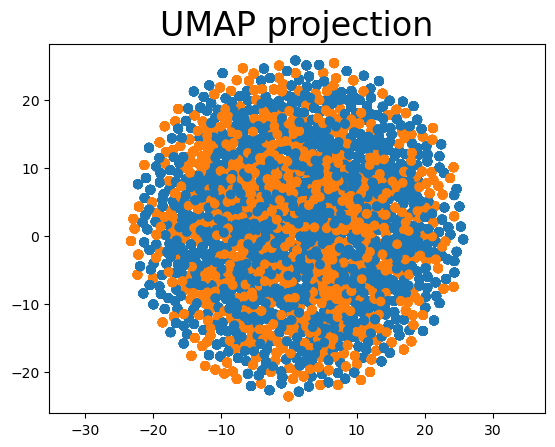

In [148]:
reducer = umap.UMAP(n_components=2)

train_embedding_umap = reducer.fit_transform(embeddings.detach().cpu().numpy())
train_y_cpu = train_ys.detach().cpu()

fig = plt.figure()
ax = fig.add_subplot()

ax.scatter(
    train_embedding_umap[:, 0],
    train_embedding_umap[:, 1],
    c=[sns.color_palette()[x] for x in train_y_cpu])

plt.gca().set_aspect('equal', 'datalim')
plt.title('UMAP projection', fontsize=24)